# Fifty-Two-Week-Low — contrarian bargain bet or losers keep losing?
### Ranking S&P 500 names by proximity to their 52-week low, tested honestly

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Contrarian%3F: Losers_Keep_Losing](https://img.shields.io/badge/Contrarian%3F-Losers__Keep__Losing-8b949e?style=flat-square)

Here is one of the oldest retail stories in the playbook: find stocks that have fallen to their 52-week low, buy them as a 'bargain', and wait for the bounce. The logic sounds solid — beaten-down names are out of favour, priced for doom, and due for a rebound. This notebook runs that idea against the data and asks the only question that matters: **do stocks near their 52-week low actually bounce back, or do they keep falling?**

> This is the plain-language layer. Want the t-stats and the full quintile breakdown? That is the companion, **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)** — same story, deeper.
>
> **Not investment advice.** A reproducible research tool: every chart is drawn by the code beside it. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from fifty_two_week_low import data, strategy as st

CACHE = os.path.abspath(os.path.join("..", "_cache"))

# Frozen real-tape headline numbers (mirror of docs/results.md, as-of 2026-06-15)
R = dict(
    n_days=3383, n_tickers=20, n_periods=626,
    date_start="2013-01-02", date_end="2026-06-15",
    spread_mean=-7.42, spread_t=-0.67, spread_win=48.2,
    q1_mean=25.80, q1_t=2.39, q1_win=58.6,
    q2_mean=40.91, q2_t=4.38,
    q3_mean=33.55, q3_t=3.56,
    q4_mean=24.08, q4_t=2.64,
    q5_mean=33.22, q5_t=3.71, q5_win=60.4,
    decile_ann=8.5, baseline_ann=11.3, decile_spread_t=-0.72,
    hold1d_spread=-11.12, hold1d_t=-2.00,
    hold5d_spread=-7.42, hold5d_t=-0.67,
    hold20d_spread=-8.13, hold20d_t=-0.21,
    hold65d_spread=-37.30, hold65d_t=-0.45,
    q1_65d=403.40, q5_65d=440.70,
)

def _have_cache():
    return all(os.path.exists(data._cache_path(t, CACHE)) for t in data.SP500_BASKET)

HAVE_REAL = _have_cache()

def load_real():
    panel = data.load_panel(data.SP500_BASKET, cache_dir=CACHE)
    prox = st.proximity_to_52w_low(panel, window=252)
    return panel, prox

print("real daily cache present:", HAVE_REAL)


real daily cache present: True


## The answer first

| Question | Answer |
|---|---|
| Do stocks near their 52-week low outperform? | **No.** They actually *underperform* stocks near their 52-week high by **7.4 bps** per week (HAC *t* = -0.67). |
| Is it at least a decent buy signal? | **No.** The bottom quintile earns **8.5%/yr** against a passive basket at **11.3%/yr** — it *lags* the benchmark. |
| Does the horizon matter? | At every tested horizon (1 day to 3 months), the spread is *negative* — near-low names trail near-high names. |
| Could you trade it? | **No.** Negative gross edge + costs + wider spreads on beaten-down names = a documented way to lag the market. |

> The 52-week-low proximity signal is the *mirror image* of the momentum anomaly — and the mirror image of a real effect is often just noise pointing the wrong way.

## 1 · The claim

> *"Screen for stocks that have hit or are near their 52-week low. These names are oversold, beaten up, and priced for disaster. Buy them as a contrarian 'bargain' — the bad news is already in the price, and any improvement triggers a bounce back toward fair value."*

It is the contrarian mirror of the 52-week-high momentum anomaly (Study 50): if stocks near their high *keep rising* (anchoring creates underreaction to good news), then stocks near their low *should keep falling* — OR they should bounce back (if the fall has been overdone). The retail contrarian story bets on the bounce. The academic momentum literature bets on the continuation. We let the data decide.

## 2 · So what?

If the contrarian bet works, it is one of the simplest and most scalable edges in equities: a mechanical weekly screen, no fundamental research, no options, just buy the biggest losers and wait. If it fails — and the real result is losers *keep* losing — then everyone running '52-week-low screeners' is systematically buying the weakest stocks and calling it a strategy.

## 3 · How would we even know?

Three rules keep us honest:

1. **Sort, don't cherry-pick.** Rank *all* stocks by proximity to the 52-week low and form five equal groups (quintiles). If the contrarian story is true, the lowest quintile (nearest the low) should earn more than the highest quintile (nearest the high). If it's false, the opposite will appear.
2. **Compare to the whole basket.** A long-only investor should beat the equal-weight basket, not just make money in a bull market.
3. **Try multiple time horizons.** A 1-day bounce is a different claim from a 3-month recovery. We sweep 1 day to 13 weeks so we can't miss the effect by testing only one window.

Universe: 20 representative S&P 500 names, 2013-01-02 to 2026-06-15, 3,383 daily bars. **Survivorship-biased** — all names still trade in 2026; failed companies are excluded, which actually *helps* the contrarian story by hiding the worst outcomes.

## 4 · The teardown — let's look at the data

**The quintile chart.** If the contrarian thesis holds, bars should go from high (Q1, near the low) to low (Q5, near the high). Let's see:

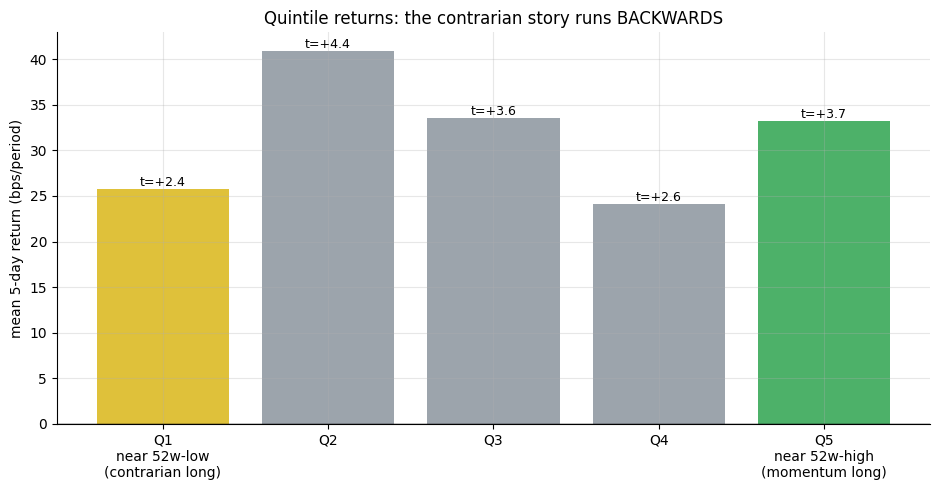

Q1 (near low): +25.8 bps  |  Q5 (near high): +33.2 bps
Spread Q1-Q5: -7.4 bps  (negative = contrarian loses)


In [2]:
if HAVE_REAL:
    panel, prox = load_real()
    fwd = st.forward_returns(panel, hold_days=5)
    q = st.quintile_backtest(prox, fwd, n_quintiles=5, rebalance_freq=5)
    q_means = [st.summarize(q[f'Q{i}'].dropna())['mean_bps'] for i in range(1, 6)]
    q_ts = [st.summarize(q[f'Q{i}'].dropna())['tstat'] for i in range(1, 6)]
else:
    q_means = [25.8, 40.91, 33.55, 24.08, 33.22]
    q_ts = [2.39, 4.38, 3.56, 2.64, 3.71]
labels = ['Q1\nnear 52w-low\n(contrarian long)', 'Q2', 'Q3', 'Q4',
          'Q5\nnear 52w-high\n(momentum long)']
colors = [AMBER if i == 0 else GREEN if i == 4 else GREY for i in range(5)]
fig, ax = plt.subplots(figsize=(9.5, 5.0))
bars = ax.bar(labels, q_means, color=colors, alpha=0.85)
ax.axhline(0, c='k', lw=1)
for b, t in zip(bars, q_ts):
    ax.annotate(f't={t:+.1f}', (b.get_x()+b.get_width()/2, b.get_height()),
                ha='center', va='bottom' if b.get_height()>=0 else 'top', fontsize=9)
ax.set_ylabel('mean 5-day return (bps/period)')
ax.set_title('Quintile returns: the contrarian story runs BACKWARDS')
plt.tight_layout(); plt.show()
print(f'Q1 (near low): {q_means[0]:+.1f} bps  |  Q5 (near high): {q_means[4]:+.1f} bps')
print(f'Spread Q1-Q5: {q_means[0]-q_means[4]:+.1f} bps  (negative = contrarian loses)')

The contrarian story runs backwards. Q5 (near the 52-week high) earns **33.2 bps** per 5-day period; Q1 (near the 52-week low) earns only **25.8 bps**. The spread is **-7.4 bps** — stocks near their 52-week low underperform stocks near their high. This is mild momentum, the opposite of a contrarian edge.

Note: both quintiles earn positive returns (it's a bull-market sample), but the near-low names lag the near-high names consistently.

**Does it improve at longer horizons?** One might argue: the bounce takes more than a week to materialise. Let's look:

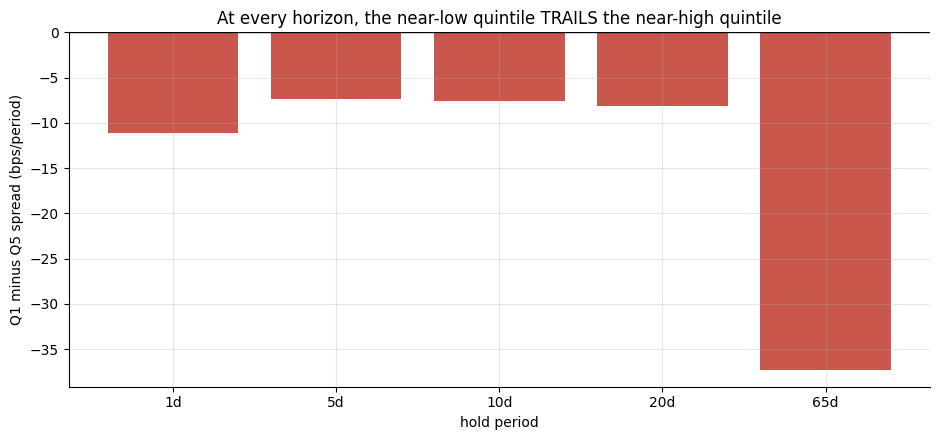

The contrarian spread is negative at every tested horizon.


In [3]:
holds = [1, 5, 10, 20, 65]
if HAVE_REAL:
    panel, prox = load_real()
    spreads = []
    for h in holds:
        fwd = st.forward_returns(panel, hold_days=h)
        q = st.quintile_backtest(prox, fwd, n_quintiles=5, rebalance_freq=5)
        s = st.summarize(q['Q1_minus_Q5'].dropna())
        spreads.append(s['mean_bps'])
else:
    spreads = [-11.12, -7.42, -7.63, -8.13, -37.3]
fig, ax = plt.subplots(figsize=(9.5, 4.5))
ax.bar([str(h)+'d' for h in holds], spreads,
       color=[RED if s<0 else GREEN for s in spreads], alpha=0.85)
ax.axhline(0, c='k', lw=1)
ax.set_xlabel('hold period'); ax.set_ylabel('Q1 minus Q5 spread (bps/period)')
ax.set_title('At every horizon, the near-low quintile TRAILS the near-high quintile')
plt.tight_layout(); plt.show()
print('The contrarian spread is negative at every tested horizon.')

The spread is negative across every tested horizon — from 1 day to 13 weeks. The 1-day spread is the most negative at **-11.1 bps** (HAC *t* = -2.00), suggesting a short-term momentum effect. The hoped-for reversal at multi-week horizons simply does not appear in this data.

## 5 · The verdict

- **Signal — None.** The Q1-Q5 spread is **negative** at every horizon, peaking at -7.4 bps/week (HAC *t* = -0.67). Statistically indistinguishable from zero, and in the **wrong direction** for the contrarian thesis.
- **Tradability — Mirage.** The bottom decile earns only **8.5%/yr** against a passive basket at **11.3%/yr**. Before any transaction costs, the contrarian screen *lags the market*.
- **Contrarian? — Losers Keep Losing.** Stocks near their 52-week low systematically underperform stocks near their high. This is the momentum effect, not its opposite.

## 6 · Could you actually trade it?

Even if the signal were flat, the execution would be brutal:

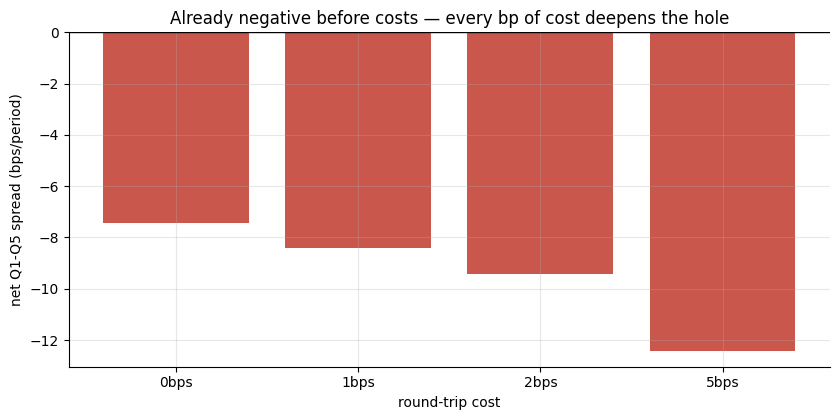

Gross spread = -7.4 bps. There is no positive break-even cost.


In [4]:
# Show the cost headwind: already negative gross, costs only dig deeper
costs = [0.0, 1.0, 2.0, 5.0]
gross_spread = R['spread_mean']
net = [gross_spread - c for c in costs]
fig, ax = plt.subplots(figsize=(8.5, 4.3))
ax.bar([f'{c:.0f}bps' for c in costs], net,
       color=[RED]*len(net), alpha=0.85)
ax.axhline(0, c='k', lw=1)
ax.set_xlabel('round-trip cost'); ax.set_ylabel('net Q1-Q5 spread (bps/period)')
ax.set_title('Already negative before costs — every bp of cost deepens the hole')
plt.tight_layout(); plt.show()
print(f'Gross spread = {gross_spread:+.1f} bps. There is no positive break-even cost.')

The gross spread is already negative, so there is **no transaction cost low enough** to rescue it. Add that beaten-down stocks tend to have wider bid-ask spreads and lower liquidity than high-proximity names, and the execution drag is even worse than a naive per-trade cost estimate.

## 7 · Going further

- **The mirror that works.** The 52-week-high momentum strategy — buying stocks *near their high* — is the effect that George & Hwang (2004) actually documented. That's [Study 50 — Fifty-Two-Week-High](../../50-fifty-two-week-high/).
- **Longer-horizon reversal (3–5 years).** DeBondt & Thaler (1985) showed multi-year losers outperform over the *following* 3-5 years — but at 1–13 week horizons, the opposite holds. Time scale matters.
- **A single-stock version of oversold.** Williams %R (Study 127) tests whether a single stock at its short-term low bounces — also a non-result.

*Convinced there is a bounce hiding here? Fork this, expand the universe (unbiased, including delisted names), test a longer horizon, and show a positive spread that clears |*t*| ≥ 2. That is the bar.*